# 02 — Exploratory Data Analysis (EDA)

This notebook explores the raw Idealista dataset collected in `01_data_collection.ipynb`.

Main goals:
- Load the latest raw dataset from `data/raw/`
- Understand dataset structure and available features
- Check missing values, duplicates, and suspicious values
- Explore price, surface, rooms, bathrooms, and location patterns
- Create first business insights for the investment opportunity project
- Prepare hypotheses for cleaning, feature engineering, and model training


## 1. Imports and project paths


In [2]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Raw data directory:", RAW_DATA_DIR.resolve())
print("Processed data directory:", PROCESSED_DATA_DIR.resolve())


Project root: C:\Users\hugol\Desktop\Python\B2\ml-poc-project
Raw data directory: C:\Users\hugol\Desktop\Python\B2\ml-poc-project\data\raw
Processed data directory: C:\Users\hugol\Desktop\Python\B2\ml-poc-project\data\processed


## 2. Load latest raw dataset

By default, this notebook loads the latest file matching:

```text
data/raw/idealista_raw_listings_*.csv
```

If needed, manually replace `csv_files[-1]` with a specific file path.


In [3]:
csv_files = sorted(RAW_DATA_DIR.glob("idealista_raw_listings_*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No raw CSV file found in {RAW_DATA_DIR}. "
        "Run notebooks/01_data_collection.ipynb first."
    )

RAW_CSV_PATH = csv_files[-1]
print("Loading:", RAW_CSV_PATH)

df = pd.read_csv(RAW_CSV_PATH)
print("Dataset shape:", df.shape)

display(df.head())


Loading: ..\data\raw\idealista_raw_listings_20260430_185730.csv
Dataset shape: (500, 51)


,propertyCode,thumbnail,externalReference,numPhotos,price,propertyType,operation,size,rooms,bathrooms,address,province,municipality,district,country,neighborhood,latitude,longitude,showAddress,url,distance,description,hasVideo,status,newDevelopment,priceByArea,hasPlan,has3DTour,has360,hasStaging,notes,topNewDevelopment,newDevelopmentHighlight,topPlus,priceInfo.price.amount,priceInfo.price.currencySuffix,parkingSpace.hasParkingSpace,parkingSpace.isParkingSpaceIncludedInPrice,detailedType.typology,detailedType.subTypology,suggestedTexts.subtitle,suggestedTexts.title,highlight.groupDescription,floor,exterior,hasLift,priceInfo.price.priceDropInfo.formerPrice,priceInfo.price.priceDropInfo.priceDropValue,priceInfo.price.priceDropInfo.priceDropPercentage,parkingSpace.parkingSpacePrice,newDevelopmentFinished
0,111308260,https://img4.idealista.com/blur/480_360_mq/0/i...,CA219287,62,"3,950,000.00",chalet,sale,603.00,7,7,calle Guarda,Madrid,Pozuelo de Alarcón,Somosaguas,es,Somosaguas,40.43,-3.78,False,https://www.idealista.com/inmueble/111308260/,6587,"En la exclusiva urbanización El Montecillo, en...",True,good,False,"6,551.00",True,True,False,False,[],False,False,True,"3,950,000.00",€,True,True,chalet,independantHouse,"Somosaguas, Pozuelo de Alarcón",Casa independiente en calle Guarda,Top+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,110715434,https://img4.idealista.com/blur/480_360_mq/0/i...,EC216671,46,"1,400,000.00",penthouse,sale,177.00,2,2,calle de Isabel la Católica,Madrid,Madrid,Centro,es,Palacio,40.42,-3.71,False,https://www.idealista.com/inmueble/110715434/,617,GILMAR Consulting Inmobiliario pone a su dispo...,True,good,False,"7,910.00",True,True,False,True,[],False,False,True,"1,400,000.00",€,NaN,NaN,flat,penthouse,"Palacio, Madrid",Ático en calle de Isabel la Católica,Top+,6,True,True,"1,500,000.00","100,000.00",7.00,NaN,NaN
2,110921969,https://img4.idealista.com/blur/480_360_mq/0/i...,NY-219592,71,"3,800,000.00",chalet,sale,"1,000.00",7,6,Barrio Somosaguas,Madrid,Pozuelo de Alarcón,Somosaguas,es,Somosaguas,40.43,-3.79,False,https://www.idealista.com/inmueble/110921969/,7775,SIN HONORARIOS A LA PARTE COMPRADORA GILMAR se...,True,renew,False,"3,800.00",True,True,False,True,[],False,False,True,"3,800,000.00",€,True,True,chalet,independantHouse,"Somosaguas, Pozuelo de Alarcón",Casa independiente,Top+,NaN,NaN,NaN,"4,200,000.00","400,000.00",10.00,NaN,NaN
3,109999723,https://img4.idealista.com/blur/480_360_mq/0/i...,DS-P22798,33,"2,100,000.00",flat,sale,137.00,3,3,calle Alcalá,Madrid,Madrid,Barrio de Salamanca,es,Goya,40.42,-3.68,False,https://www.idealista.com/inmueble/109999723/,2404,DIZA Consultores les presenta este fantástico ...,True,good,False,"15,328.00",True,True,False,True,[],False,False,True,"2,100,000.00",€,NaN,NaN,flat,NaN,"Goya, Madrid",Piso en calle Alcalá,Top+,3,True,True,"2,300,000.00","200,000.00",9.00,NaN,NaN
4,103883825,https://img4.idealista.com/blur/480_360_mq/0/i...,AS192516,51,"4,950,000.00",flat,sale,383.00,5,3,calle Maldonado,Madrid,Madrid,Barrio de Salamanca,es,Castellana,40.43,-3.68,False,https://www.idealista.com/inmueble/103883825/,2523,En el corazón del prestigioso barrio de Salama...,True,good,False,"12,924.00",True,True,False,True,[],False,False,True,"4,950,000.00",€,NaN,NaN,flat,NaN,"Castellana, Madrid",Piso en calle Maldonado,Top+,6,True,True,NaN,NaN,NaN,NaN,NaN


## 3. Dataset overview


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
}).sort_values("missing_pct", ascending=False)

display(overview)


Rows: 500
Columns: 51


,column,dtype,missing_count,missing_pct,unique_values
50,newDevelopmentFinished,object,495,99.00,2
49,parkingSpace.parkingSpacePrice,float64,483,96.60,9
46,priceInfo.price.priceDropInfo.formerPrice,float64,411,82.20,68
48,priceInfo.price.priceDropInfo.priceDropPercentage,float64,411,82.20,12
47,priceInfo.price.priceDropInfo.priceDropValue,float64,411,82.20,37
39,detailedType.subTypology,object,340,68.00,6
36,parkingSpace.hasParkingSpace,object,259,51.80,1
37,parkingSpace.isParkingSpaceIncludedInPrice,object,259,51.80,2
43,floor,object,100,20.00,16
44,exterior,object,95,19.00,2


## 4. Key columns check

The project mainly needs variables related to:
- price
- size
- location
- property characteristics
- amenities
- listing identifiers


In [5]:
expected_columns = [
    "propertyCode", "price", "size", "rooms", "bathrooms",
    "district", "neighborhood", "municipality", "province",
    "propertyType", "operation", "url",
    "latitude", "longitude",
    "floor", "hasLift", "exterior", "parkingSpace.hasParkingSpace"
]

available_expected = [col for col in expected_columns if col in df.columns]
missing_expected = [col for col in expected_columns if col not in df.columns]

print("Available expected columns:")
print(available_expected)

print("\nMissing expected columns:")
print(missing_expected)

display(df[available_expected].head())


Available expected columns:
['propertyCode', 'price', 'size', 'rooms', 'bathrooms', 'district', 'neighborhood', 'municipality', 'province', 'propertyType', 'operation', 'url', 'latitude', 'longitude', 'floor', 'hasLift', 'exterior', 'parkingSpace.hasParkingSpace']

Missing expected columns:
[]


,propertyCode,price,size,rooms,bathrooms,district,neighborhood,municipality,province,propertyType,operation,url,latitude,longitude,floor,hasLift,exterior,parkingSpace.hasParkingSpace
0,111308260,"3,950,000.00",603.00,7,7,Somosaguas,Somosaguas,Pozuelo de Alarcón,Madrid,chalet,sale,https://www.idealista.com/inmueble/111308260/,40.43,-3.78,NaN,NaN,NaN,True
1,110715434,"1,400,000.00",177.00,2,2,Centro,Palacio,Madrid,Madrid,penthouse,sale,https://www.idealista.com/inmueble/110715434/,40.42,-3.71,6,True,True,NaN
2,110921969,"3,800,000.00","1,000.00",7,6,Somosaguas,Somosaguas,Pozuelo de Alarcón,Madrid,chalet,sale,https://www.idealista.com/inmueble/110921969/,40.43,-3.79,NaN,NaN,NaN,True
3,109999723,"2,100,000.00",137.00,3,3,Barrio de Salamanca,Goya,Madrid,Madrid,flat,sale,https://www.idealista.com/inmueble/109999723/,40.42,-3.68,3,True,True,NaN
4,103883825,"4,950,000.00",383.00,5,3,Barrio de Salamanca,Castellana,Madrid,Madrid,flat,sale,https://www.idealista.com/inmueble/103883825/,40.43,-3.68,6,True,True,NaN


## 5. Duplicate listings

Listings can appear more than once across API pages or collection runs.  
The main unique identifier is usually `propertyCode`.


In [6]:
if "propertyCode" in df.columns:
    duplicate_count = df["propertyCode"].duplicated().sum()
    duplicate_pct = duplicate_count / len(df) * 100
    print(f"Duplicate propertyCode count: {duplicate_count}")
    print(f"Duplicate percentage: {duplicate_pct:.2f}%")

    if duplicate_count > 0:
        display(df[df["propertyCode"].duplicated(keep=False)].sort_values("propertyCode").head(20))
else:
    print("propertyCode column not found.")


Duplicate propertyCode count: 0
Duplicate percentage: 0.00%


## 6. Basic type cleaning for EDA

This is not the final cleaning pipeline.  
The goal is only to make exploratory analysis easier.


In [7]:
df_eda = df.copy()

numeric_candidates = [
    "price", "size", "rooms", "bathrooms", "latitude", "longitude"
]

for col in numeric_candidates:
    if col in df_eda.columns:
        df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

if "propertyCode" in df_eda.columns:
    before = len(df_eda)
    df_eda = df_eda.drop_duplicates(subset=["propertyCode"], keep="first")
    after = len(df_eda)
    print(f"Dropped {before - after} duplicated listings for EDA.")

print("EDA dataset shape:", df_eda.shape)


Dropped 0 duplicated listings for EDA.
EDA dataset shape: (500, 51)


## 7. Basic statistics


In [8]:
numeric_cols = [col for col in ["price", "size", "rooms", "bathrooms"] if col in df_eda.columns]
display(df_eda[numeric_cols].describe())

categorical_cols = [col for col in ["district", "neighborhood", "municipality", "province", "propertyType"] if col in df_eda.columns]

for col in categorical_cols:
    print(f"\nTop values for {col}:")
    display(df_eda[col].value_counts(dropna=False).head(15))


,price,size,rooms,bathrooms
count,500.00,500.00,500.00,500.00
mean,"2,268,730.80",269.46,3.56,3.35
std,"1,934,836.89",258.77,1.58,1.83
min,"300,000.00",37.00,0.00,1.00
25%,"1,052,500.00",119.75,2.00,2.00
50%,"1,787,500.00",186.00,3.00,3.00
75%,"2,780,000.00",300.75,4.00,4.00
max,"15,000,000.00","1,700.00",9.00,11.00



Top values for district:


district
Barrio de Salamanca                    132
Centro                                  63
Chamberí                                57
Chamartín                               42
Retiro                                  32
Moncloa                                 29
Hortaleza                               28
La Moraleja urbanización                16
Fuencarral                              14
Zona Prado de Somosaguas - La Finca     11
Somosaguas                              11
El Soto de la Moraleja                  10
Tetuán                                  10
Arganzuela                               9
Encinar de los Reyes                     8
Name: count, dtype: int64


Top values for neighborhood:


neighborhood
Goya                             43
NaN                              42
Castellana                       35
Recoletos                        32
El Viso                          22
Malasaña-Universidad             20
Trafalgar                        16
Conde Orgaz-Piovera              15
Almagro                          14
Chueca-Justicia                  13
Somosaguas                       11
Palacio                          11
Nuevos Ministerios-Ríos Rosas    11
Lista                            11
Ibiza                            11
Name: count, dtype: int64

...

municipality
Madrid                424
La Moraleja            37
Pozuelo de Alarcón     34
Boadilla del Monte      4
Majadahonda             1
Name: count, dtype: int64


Top values for province:


province
Madrid    500
Name: count, dtype: int64


Top values for propertyType:


propertyType
flat         338
chalet        92
penthouse     58
duplex        10
studio         2
Name: count, dtype: int64

## 8. Create first derived feature: price per square meter

`price_per_m2` is one of the most important real estate indicators.


In [9]:
if "price" in df_eda.columns and "size" in df_eda.columns:
    df_eda["price_per_m2"] = np.where(
        df_eda["size"] > 0,
        df_eda["price"] / df_eda["size"],
        np.nan
    )

    display(df_eda[["price", "size", "price_per_m2"]].describe())
else:
    print("price and/or size columns not found.")


,price,size,price_per_m2
count,500.00,500.00,500.00
mean,"2,268,730.80",269.46,"9,488.26"
std,"1,934,836.89",258.77,"3,637.07"
min,"300,000.00",37.00,"2,941.18"
25%,"1,052,500.00",119.75,"6,725.15"
50%,"1,787,500.00",186.00,"8,656.11"
75%,"2,780,000.00",300.75,"11,691.18"
max,"15,000,000.00","1,700.00","23,750.00"


## 9. Outlier inspection

We do **not** remove outliers permanently here.  
We only create an EDA-filtered dataset to make charts easier to interpret.


In [10]:
df_plot = df_eda.copy()

if "price" in df_plot.columns:
    df_plot = df_plot[df_plot["price"].between(50_000, 5_000_000)]

if "size" in df_plot.columns:
    df_plot = df_plot[df_plot["size"].between(20, 500)]

if "price_per_m2" in df_plot.columns:
    df_plot = df_plot[df_plot["price_per_m2"].between(500, 25_000)]

print("Original EDA shape:", df_eda.shape)
print("Plot-filtered shape:", df_plot.shape)


Original EDA shape: (500, 52)
Plot-filtered shape: (434, 52)


## 10. Raw data visualization — price distribution

This visualization helps identify price dispersion and extreme values.


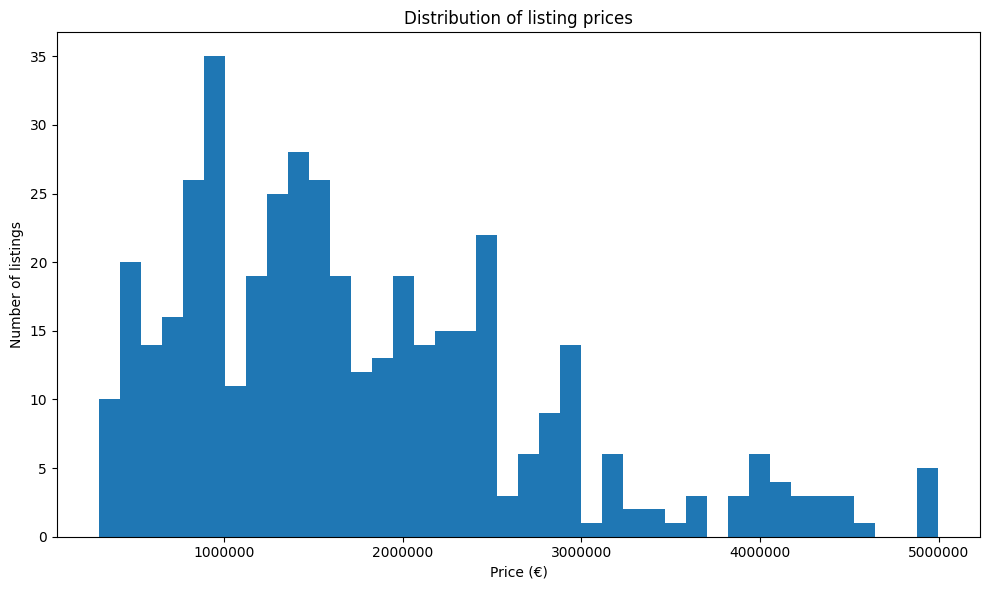

Saved figure: ..\reports\figures\eda_price_distribution.png


In [11]:
if "price" in df_plot.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_plot["price"].dropna(), bins=40)
    plt.title("Distribution of listing prices")
    plt.xlabel("Price (€)")
    plt.ylabel("Number of listings")
    plt.ticklabel_format(style="plain", axis="x")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_price_distribution.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)


## 11. Surface distribution


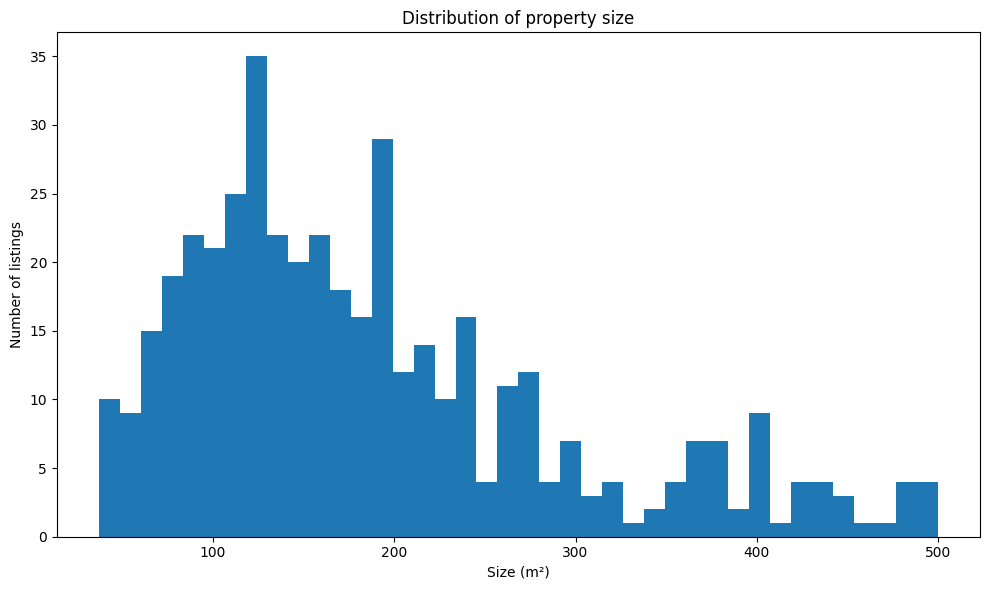

Saved figure: ..\reports\figures\eda_size_distribution.png


In [12]:
if "size" in df_plot.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_plot["size"].dropna(), bins=40)
    plt.title("Distribution of property size")
    plt.xlabel("Size (m²)")
    plt.ylabel("Number of listings")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_size_distribution.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)


## 12. Feature-engineered visualization — price per m² by district

This is central to the business problem: location strongly affects fair market value.


,listings,avg_price,median_price,avg_size,avg_price_per_m2,median_price_per_m2
district,,,,,,
Barrio de Salamanca,126,"2,137,676.98","1,980,000.00",170.14,"12,837.18","12,675.64"
Chamberí,57,"1,620,789.47","1,400,000.00",162.56,"10,075.64","10,051.55"
Retiro,31,"1,404,593.55","1,178,000.00",130.61,"10,189.19","9,637.10"
Chamartín,38,"1,945,184.21","1,667,500.00",204.89,"9,491.10","9,271.33"
La Moraleja urbanización,7,"3,714,285.71","4,100,000.00",447.86,"8,293.67","8,854.17"
Centro,62,"1,247,966.13","1,042,500.00",147.13,"8,561.92","8,069.30"
Arganzuela,9,"690,111.11","560,000.00",89.67,"7,720.44","7,671.23"
Tetuán,10,"1,503,500.00","1,487,500.00",199.70,"7,750.83","7,407.12"
Encinar de los Reyes,8,"1,953,750.00","1,665,000.00",274.00,"7,229.14","7,263.29"


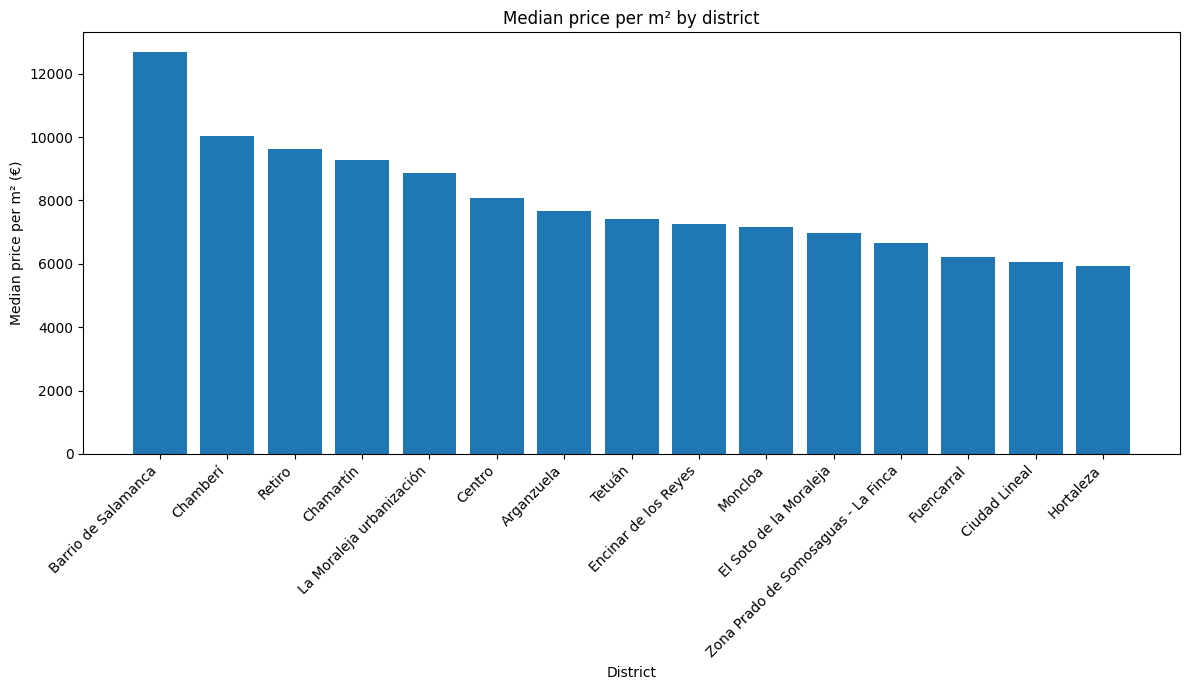

Saved figure: ..\reports\figures\eda_price_per_m2_by_district.png


In [13]:
if "district" in df_plot.columns and "price_per_m2" in df_plot.columns:
    count_col = "propertyCode" if "propertyCode" in df_plot.columns else "price_per_m2"
    district_summary = (
        df_plot
        .groupby("district")
        .agg(
            listings=(count_col, "count"),
            avg_price=("price", "mean"),
            median_price=("price", "median"),
            avg_size=("size", "mean"),
            avg_price_per_m2=("price_per_m2", "mean"),
            median_price_per_m2=("price_per_m2", "median")
        )
        .sort_values("median_price_per_m2", ascending=False)
    )

    display(district_summary.head(20))

    top_districts = district_summary[district_summary["listings"] >= 5].head(15)

    plt.figure(figsize=(12, 7))
    plt.bar(top_districts.index.astype(str), top_districts["median_price_per_m2"])
    plt.title("Median price per m² by district")
    plt.xlabel("District")
    plt.ylabel("Median price per m² (€)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_price_per_m2_by_district.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)
else:
    print("district or price_per_m2 column not found.")


## 13. Relationship between size and price


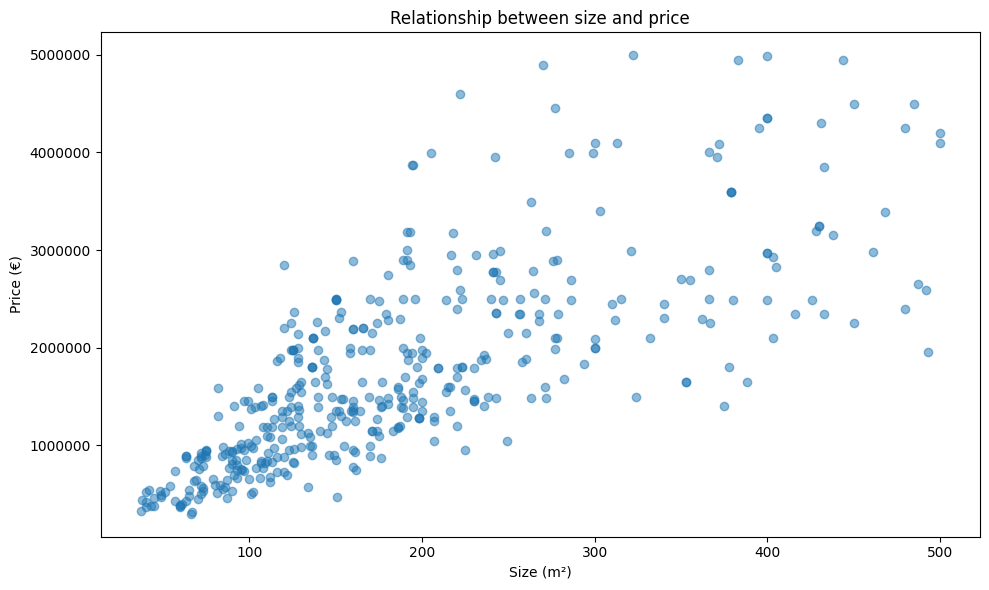

Saved figure: ..\reports\figures\eda_size_vs_price.png


In [14]:
if "size" in df_plot.columns and "price" in df_plot.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_plot["size"], df_plot["price"], alpha=0.5)
    plt.title("Relationship between size and price")
    plt.xlabel("Size (m²)")
    plt.ylabel("Price (€)")
    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_size_vs_price.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)


## 14. Rooms and bathrooms analysis



Price analysis by rooms:


,listings,median_price,median_price_per_m2
rooms,,,
0,2,"462,500.00","9,520.24"
1,22,"525,000.00","7,803.51"
2,108,"975,000.00","10,521.32"
3,152,"1,475,000.00","9,270.73"
4,85,"2,100,000.00","8,470.15"
5,44,"2,495,000.00","7,457.07"
6,17,"2,980,000.00","8,354.29"
7,2,"2,150,000.00","5,057.85"
8,2,"2,325,000.00","5,645.74"


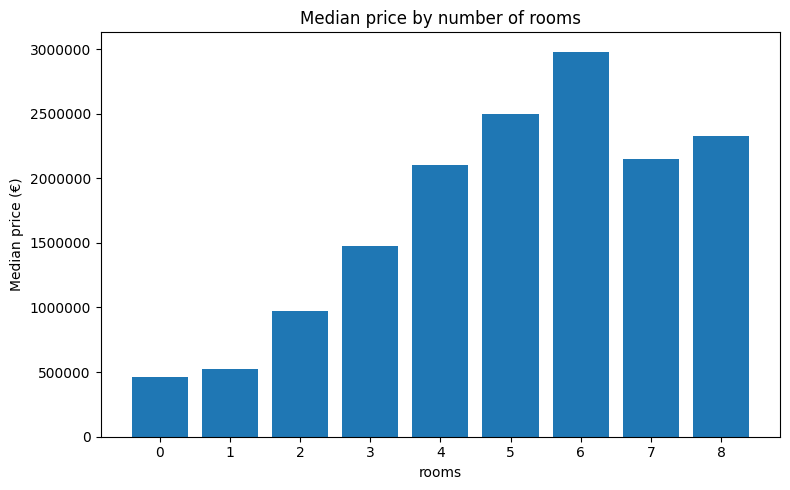

Saved figure: ..\reports\figures\eda_median_price_by_rooms.png

Price analysis by bathrooms:


,listings,median_price,median_price_per_m2
bathrooms,,,
1,52,"534,500.00","8,069.30"
2,147,"1,185,000.00","9,732.14"
3,108,"1,855,000.00","9,161.83"
4,73,"2,290,000.00","9,278.35"
5,40,"2,780,000.00","8,872.81"
6,13,"2,990,000.00","7,476.64"
7,1,"4,200,000.00","8,400.00"


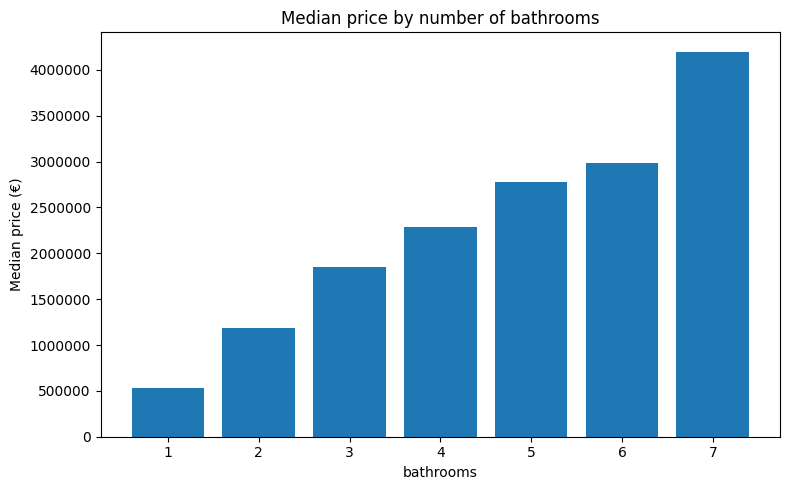

Saved figure: ..\reports\figures\eda_median_price_by_bathrooms.png


In [15]:
for col in ["rooms", "bathrooms"]:
    if col in df_plot.columns and "price" in df_plot.columns:
        agg_dict = {
            "listings": ("price", "count"),
            "median_price": ("price", "median")
        }
        if "price_per_m2" in df_plot.columns:
            agg_dict["median_price_per_m2"] = ("price_per_m2", "median")

        grouped = df_plot.groupby(col).agg(**agg_dict).sort_index()
        print(f"\nPrice analysis by {col}:")
        display(grouped)

        plt.figure(figsize=(8, 5))
        plt.bar(grouped.index.astype(str), grouped["median_price"])
        plt.title(f"Median price by number of {col}")
        plt.xlabel(col)
        plt.ylabel("Median price (€)")
        plt.ticklabel_format(style="plain", axis="y")
        plt.tight_layout()

        fig_path = REPORTS_DIR / f"eda_median_price_by_{col}.png"
        plt.savefig(fig_path, dpi=150)
        plt.show()

        print("Saved figure:", fig_path)


## 15. Amenities analysis

Depending on the API response, amenities may appear as columns such as:
- `hasLift`
- `exterior`
- `parkingSpace.hasParkingSpace`
- `hasVideo`
- `hasPlan`


In [16]:
amenity_candidates = [
    "hasLift",
    "exterior",
    "parkingSpace.hasParkingSpace",
    "hasVideo",
    "hasPlan",
    "has3DTour",
    "newDevelopment"
]

amenity_cols = [col for col in amenity_candidates if col in df_plot.columns]

print("Available amenity columns:")
print(amenity_cols)

for col in amenity_cols:
    print(f"\n{col} value counts:")
    display(df_plot[col].value_counts(dropna=False))

    if "price_per_m2" in df_plot.columns:
        amenity_summary = (
            df_plot
            .groupby(col)
            .agg(
                listings=("price_per_m2", "count"),
                median_price_per_m2=("price_per_m2", "median"),
                median_price=("price", "median")
            )
        )
        display(amenity_summary)


Available amenity columns:
['hasLift', 'exterior', 'parkingSpace.hasParkingSpace', 'hasVideo', 'hasPlan', 'has3DTour', 'newDevelopment']

hasLift value counts:


hasLift
True     379
NaN       39
False     16
Name: count, dtype: int64

,listings,median_price_per_m2,median_price
hasLift,,,
False,16,"6,569.95","761,950.00"
True,379,"9,577.92","1,486,000.00"



exterior value counts:


exterior
True     354
NaN       42
False     38
Name: count, dtype: int64

...

has3DTour
False    249
True     185
Name: count, dtype: int64

,listings,median_price_per_m2,median_price
has3DTour,,,
False,249,"9,637.10","1,450,000.00"
True,185,"8,400.00","1,590,000.00"



newDevelopment value counts:


newDevelopment
False    430
True       4
Name: count, dtype: int64

,listings,median_price_per_m2,median_price
newDevelopment,,,
False,430,"9,000.00","1,497,000.00"
True,4,"9,033.59","2,140,000.00"


## 16. Correlation analysis

This helps identify numerical variables that may be useful for prediction.


,price,size,rooms,bathrooms,price_per_m2,latitude,longitude
price,1.00,0.76,0.56,0.69,0.40,0.13,0.09
size,0.76,1.00,0.80,0.78,-0.23,0.40,-0.02
rooms,0.56,0.80,1.00,0.72,-0.25,0.35,-0.10
bathrooms,0.69,0.78,0.72,1.00,-0.03,0.31,-0.00
price_per_m2,0.40,-0.23,-0.25,-0.03,1.00,-0.34,0.13
latitude,0.13,0.40,0.35,0.31,-0.34,1.00,0.31
longitude,0.09,-0.02,-0.10,-0.00,0.13,0.31,1.00


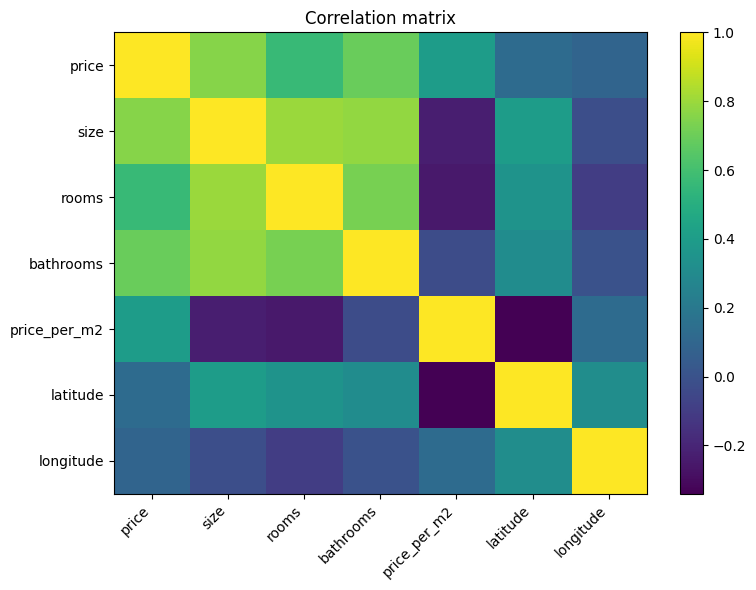

Saved figure: ..\reports\figures\eda_correlation_matrix.png


In [17]:
corr_candidates = [
    "price", "size", "rooms", "bathrooms", "price_per_m2",
    "latitude", "longitude"
]
corr_cols = [col for col in corr_candidates if col in df_plot.columns]

if len(corr_cols) >= 2:
    corr = df_plot[corr_cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation matrix")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_correlation_matrix.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)
else:
    print("Not enough numerical columns for correlation analysis.")


## 17. Optional map visualization

If latitude and longitude are available, this map gives a first view of spatial patterns.

If Plotly is not installed:

```bash
pip install plotly
```


In [19]:
if {"latitude", "longitude"}.issubset(df_plot.columns):
    try:
        import plotly.express as px

        map_df = df_plot.dropna(subset=["latitude", "longitude", "price"])

        hover_cols = [col for col in ["price", "size", "rooms", "bathrooms", "price_per_m2", "url"] if col in map_df.columns]

        fig = px.scatter_mapbox(
            map_df,
            lat="latitude",
            lon="longitude",
            color="price_per_m2" if "price_per_m2" in map_df.columns else "price",
            size="price",
            hover_name="district" if "district" in map_df.columns else None,
            hover_data=hover_cols,
            zoom=10,
            height=600,
            title="Idealista listings map"
        )
        fig.update_layout(mapbox_style="open-street-map")
        fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0})
        fig.show()
    except ImportError:
        print("Plotly is not installed. Run: pip install plotly")
else:
    print("latitude and/or longitude not available.")


C:\Users\hugol\AppData\Local\Temp\ipykernel_4760\3037641286.py:9: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 18. Description keyword analysis

This simple text analysis identifies business-relevant keywords in listing descriptions.


Using description column: description


,count
exterior,267
terraza,230
garaje,227
lujo,199
oportunidad,193
piscina,163
ascensor,158
exclusivo,143
luminoso,128
ático,119


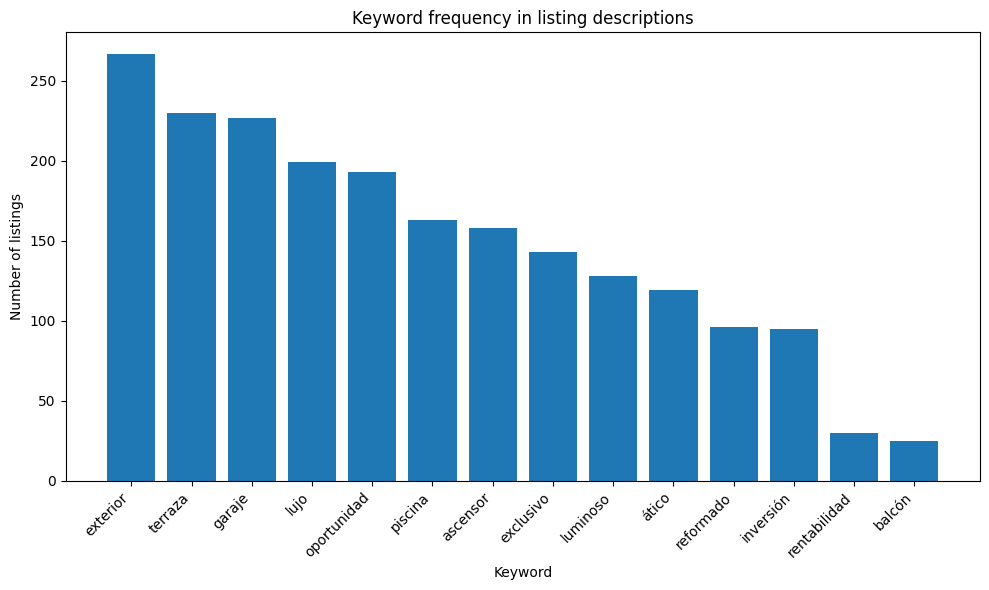

Saved figure: ..\reports\figures\eda_description_keywords.png


In [20]:
description_col = None
for candidate in ["description", "propertyComment", "suggestedTexts.subtitle"]:
    if candidate in df_eda.columns:
        description_col = candidate
        break

keywords = [
    "reformado", "terraza", "ático", "luminoso", "exterior",
    "garaje", "ascensor", "lujo", "exclusivo", "oportunidad",
    "rentabilidad", "inversión", "piscina", "balcón"
]

if description_col:
    print("Using description column:", description_col)

    text_series = df_eda[description_col].fillna("").astype(str).str.lower()

    keyword_counts = {}
    for kw in keywords:
        keyword_counts[kw] = text_series.str.contains(kw, regex=False).sum()

    keyword_df = (
        pd.DataFrame.from_dict(keyword_counts, orient="index", columns=["count"])
        .sort_values("count", ascending=False)
    )

    display(keyword_df)

    plt.figure(figsize=(10, 6))
    plt.bar(keyword_df.index, keyword_df["count"])
    plt.title("Keyword frequency in listing descriptions")
    plt.xlabel("Keyword")
    plt.ylabel("Number of listings")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    fig_path = REPORTS_DIR / "eda_description_keywords.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved figure:", fig_path)
else:
    print("No description-like column found.")


## 19. First investment-opportunity proxy

This is not the final model.  
It is a first business-oriented indicator for exploration:

- Compute average price per m² by district
- Compare each listing against its district average
- Negative values may indicate potential underpricing


In [21]:
if "district" in df_eda.columns and "price_per_m2" in df_eda.columns:
    df_eda["district_avg_price_per_m2"] = (
        df_eda.groupby("district")["price_per_m2"].transform("mean")
    )

    df_eda["discount_vs_district_avg_pct"] = (
        (df_eda["price_per_m2"] - df_eda["district_avg_price_per_m2"])
        / df_eda["district_avg_price_per_m2"]
        * 100
    )

    opportunity_cols = [
        "propertyCode", "district", "price", "size", "rooms", "bathrooms",
        "price_per_m2", "district_avg_price_per_m2",
        "discount_vs_district_avg_pct", "url"
    ]
    opportunity_cols = [col for col in opportunity_cols if col in df_eda.columns]

    opportunities = (
        df_eda
        .dropna(subset=["discount_vs_district_avg_pct"])
        .sort_values("discount_vs_district_avg_pct")
        [opportunity_cols]
        .head(20)
    )

    display(opportunities)
else:
    print("district or price_per_m2 column not available.")


,propertyCode,district,price,size,rooms,bathrooms,price_per_m2,district_avg_price_per_m2,discount_vs_district_avg_pct,url
155,101541026,Moncloa,"5,000,000.00","1,700.00",4,6,"2,941.18","6,882.77",-57.27,https://www.idealista.com/inmueble/101541026/
271,109466534,Barrio de Salamanca,"530,000.00",90.00,2,2,"5,888.89","13,044.90",-54.86,https://www.idealista.com/inmueble/109466534/
224,110152501,Retiro,"320,000.00",67.00,2,1,"4,776.12","10,433.34",-54.22,https://www.idealista.com/inmueble/110152501/
199,110854014,Barrio de Salamanca,"370,000.00",60.00,2,1,"6,166.67","13,044.90",-52.73,https://www.idealista.com/inmueble/110854014/
437,111161241,Barrio de Salamanca,"1,190,000.00",186.00,4,2,"6,397.85","13,044.90",-50.96,https://www.idealista.com/inmueble/111161241/
369,107800957,Centro,"575,000.00",134.00,3,3,"4,291.04","8,730.59",-50.85,https://www.idealista.com/inmueble/107800957/
496,111207210,Centro,"300,000.00",66.00,1,1,"4,545.45","8,730.59",-47.94,https://www.idealista.com/inmueble/111207210/
58,110541536,Ciudad Lineal,"470,000.00",151.00,3,2,"3,112.58","5,970.12",-47.86,https://www.idealista.com/inmueble/110541536/
219,110884163,Retiro,"630,000.00",112.00,2,2,"5,625.00","10,433.34",-46.09,https://www.idealista.com/inmueble/110884163/
477,110232321,Barrio de Salamanca,"670,000.00",93.00,1,1,"7,204.30","13,044.90",-44.77,https://www.idealista.com/inmueble/110232321/


## 20. Export EDA-enriched dataset

This dataset is not the final cleaned modeling dataset.  
It includes useful EDA features that will guide the next notebook.


In [22]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

eda_output_path = PROCESSED_DATA_DIR / f"idealista_eda_enriched_{timestamp}.csv"
df_eda.to_csv(eda_output_path, index=False, encoding="utf-8-sig")

print("EDA-enriched dataset saved to:", eda_output_path)
print("Shape:", df_eda.shape)


EDA-enriched dataset saved to: ..\data\processed\idealista_eda_enriched_20260505_091509.csv
Shape: (500, 54)
